For evaluation (Phase without model)

## 1. Configuration

In [1]:
import os

# Ensure 100% CPU execution (disable GPU)
os.environ["CUDA_VISIBLE_DEVICES"] = ""

# Directory and subset controls
BASE_OUT_DIR = "out/merged/second-test"
EVAL_MAX_SAMPLES = None
SAMPLE_COUNT_TOL = 10
INPUT_CACHE_DIR = "out/merged-test"


# Target models
TARGET_MODELS = [
    {"id": "Baseline", "config": "configs/baseline.yaml", "folder": "baseline_text2cad", "color": "#4A6572"},
    {"id": "M1", "config": "configs/m1.yaml", "folder": "m1", "color": "#00887A"},
    {"id": "M2", "config": "configs/m2.yaml", "folder": "m2", "color": "#00A896"},
    {"id": "M3", "config": "configs/m3-xx.yaml", "folder": "m3", "color": "#D35400"},
    {"id": "M4", "config": "configs/m4-xx.yaml", "folder": "grpo_fuse", "color": "#C0392B"},
]

TEST_OUT_DIR = os.path.join(BASE_OUT_DIR, "test")
VAL_OUT_DIR = os.path.join(BASE_OUT_DIR, "val")

os.makedirs(os.path.join(TEST_OUT_DIR, "visualizations/top50_least_cd"), exist_ok=True)
os.makedirs(os.path.join(TEST_OUT_DIR, "visualizations/top50_most_cd"), exist_ok=True)
os.makedirs(os.path.join(VAL_OUT_DIR, "visualizations/top50_least_cd"), exist_ok=True)
os.makedirs(os.path.join(VAL_OUT_DIR, "visualizations/top50_most_cd"), exist_ok=True)

## 2. Imports

In [2]:
import sys
import time
import json
import gc
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

from utils.pipeline import load_config
from utils.data_utils import load_val_data, load_test_data
from utils.dual_seq import DualSeq
from utils.representations.dual_seq.metadata import DualSeqMetadata
from utils.representations.dual_seq.schema import DEFAULT_COMMANDS
from utils.representations.CadSeqProc.cad_sequence import CADSequence
from utils.representations.converter import dualseq_to_cadseq
from utils.evaluate import eval_cmd_only
from utils.render import (
    render_dual_seq_to_shape,
    render_to_image,
    render_model_comparison_grid,
    sample_shape,
)
from utils.evaluate.render.chamfer_distance import (
    chamfer_distance,
    chamfer_distance_from_shapes,
    invalidity_rate_from_shapes,
)
from utils.others.shape_eval_utils import (
    make_cube,
    make_cylinder,
    make_cylinder_on_top,
)

/home/alief/miniconda3/envs/kaggle/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.stats import gaussian_kde


## 3. Helpers

In [3]:
def unify_model_prediction(pred_out, uid: str = "") -> tuple:
    if pred_out is None:
        return None, None
    if isinstance(pred_out, CADSequence):
        cad_obj = pred_out
        try:
            json_data = cad_obj._json() if hasattr(cad_obj, "_json") else {}
            if json_data and "parts" in json_data:
                ds_obj = DualSeq(json_object=json_data, uid=uid)
            else:
                ds_obj = DualSeq(cmds=[], args=[], uid=uid)
        except Exception:
            ds_obj = DualSeq(cmds=[], args=[], uid=uid)
        return ds_obj, cad_obj
    elif isinstance(pred_out, DualSeq):
        ds_obj = pred_out
        try:
            cad_obj = dualseq_to_cadseq(ds_obj)
        except Exception:
            cad_obj = None
        return ds_obj, cad_obj
    return None, None

def resolve_cache_path(out_model_dir: str, split_prefix: str) -> str:
    return os.path.join(out_model_dir, f"{split_prefix}_predictions.pkl")

def validate_and_load_cache(pred_pkl_path: str, samples: list, model_id: str, split_name: str, tolerance: int = SAMPLE_COUNT_TOL) -> dict:
    if not os.path.exists(pred_pkl_path):
        raise FileNotFoundError(f"Cache file not found at {pred_pkl_path} for model {model_id} ({split_name})")
    with open(pred_pkl_path, "rb") as f:
        cached_preds = pickle.load(f)
    return cached_preds

def paired_mean_diff(x, y, axis=-1):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

def paired_median_diff(x, y, axis=-1):
    return np.median(x, axis=axis) - np.median(y, axis=axis)

# Metadata loader for bin / token error calculation
def get_dual_seq_metadata():
    metadata_candidates = [
        "out/m3/dual_seq_metadata.pkl",
        "out/m4-xx/dual_seq_metadata.pkl",
        "out/m2/dual_seq_metadata.pkl",
    ]
    for p in metadata_candidates:
        if os.path.exists(p):
            return DualSeqMetadata.load(p)
    return None

DUAL_SEQ_METADATA = get_dual_seq_metadata()

def evaluate_args_and_token_error(pred_cmds, pred_args, gt_cmds, gt_args, metadata=None):
    correct_args = 0
    total_gt_args = 0
    total_pred_args = sum(len(p_dict) for p_dict in pred_args) if pred_args else 0
    
    arc_token_errors = []
    arg_token_errors = []
    
    min_steps = min(len(pred_args), len(gt_args))
    for step_i in range(min_steps):
        p_dict, g_dict = pred_args[step_i], gt_args[step_i]
        p_cmd = pred_cmds[step_i] if step_i < len(pred_cmds) else ""
        g_cmd = gt_cmds[step_i] if step_i < len(gt_cmds) else ""
        
        for k_arg, v_gt in g_dict.items():
            total_gt_args += 1
            if k_arg in p_dict:
                v_pred = p_dict[k_arg]
                if abs(float(v_pred) - float(v_gt)) < 1e-2:
                    correct_args += 1
                
                if metadata is not None:
                    try:
                        t_gt = metadata.float_to_bin(k_arg, float(v_gt))
                        t_pred = metadata.float_to_bin(k_arg, float(v_pred))
                        err = abs(t_pred - t_gt)
                        arg_token_errors.append(err)
                        if g_cmd == "ARC" and k_arg in DEFAULT_COMMANDS.get("ARC", []):
                            arc_token_errors.append(err)
                    except Exception:
                        pass
                        
    for step_i in range(min_steps, len(gt_args)):
        total_gt_args += len(gt_args[step_i])
        
    prec = correct_args / max(total_pred_args, 1) if total_pred_args > 0 else 0.0
    rec = correct_args / max(total_gt_args, 1) if total_gt_args > 0 else 0.0
    f1 = (2.0 * prec * rec / (prec + rec)) if (prec + rec) > 0.0 else 0.0
    acc = correct_args / max(total_gt_args, 1) if total_gt_args > 0 else 0.0
    
    mean_arc_err = float(np.mean(arc_token_errors)) if arc_token_errors else np.nan
    median_arc_err = float(np.median(arc_token_errors)) if arc_token_errors else np.nan
    mean_arg_err = float(np.mean(arg_token_errors)) if arg_token_errors else np.nan
    median_arg_err = float(np.median(arg_token_errors)) if arg_token_errors else np.nan
    
    return {
        "f1_args": f1,
        "acc_args": acc,
        "prec_args": prec,
        "rec_args": rec,
        "mean_arc_token_err": mean_arc_err,
        "median_arc_token_err": median_arc_err,
        "arc_token_errors": arc_token_errors,
        "mean_arg_token_err": mean_arg_err,
        "median_arg_token_err": median_arg_err,
        "arg_token_errors": arg_token_errors,
    }

## 4. Smoke Figures Test

In [4]:
cube1 = make_cube(1.0)
cube2 = make_cube(1.0)
cyl = make_cylinder(0.5, 1.0)
cyl_top = make_cylinder_on_top(1.0, 0.3, 0.5)

cd_cube_cube = chamfer_distance_from_shapes(cube1, cube2)
cd_cube_cyl = chamfer_distance_from_shapes(cube1, cyl)
cd_cube_cyl_top = chamfer_distance_from_shapes(cube1, cyl_top)
cd_cyl_cyl_top = chamfer_distance_from_shapes(cyl, cyl_top)

print(f"CD(cube, cube)       = {cd_cube_cube:.6f}")
print(f"CD(cube, cylinder)   = {cd_cube_cyl:.6f}")
print(f"CD(cube, cyl_on_top) = {cd_cube_cyl_top:.6f}")
print(f"CD(cyl, cyl_on_top)  = {cd_cyl_cyl_top:.6f}")

assert cd_cube_cube == 0.0

CD(cube, cube)       = 0.000000
CD(cube, cylinder)   = 0.648914
CD(cube, cyl_on_top) = 0.273179
CD(cyl, cyl_on_top)  = 0.467847


# PART 1: TEST SET EVALUATION

### Load

In [5]:
base_cfg = load_config(TARGET_MODELS[0]["config"])
all_test_samples = load_test_data(
    data_folder=base_cfg.data.data_folder,
    metadata_csv=base_cfg.data.metadata_csv,
    split_json=base_cfg.data.split_json
)
test_samples = all_test_samples[:EVAL_MAX_SAMPLES] if EVAL_MAX_SAMPLES is not None else all_test_samples


Loading CSV from: /home/alief/prjkcad/data/text2cad/text2cad_v1.1.csv
Processing 8046 rows to load JSON payloads...


100%|██████████| 8046/8046 [00:00<00:00, 15363.31it/s]

Successfully created 8042/8046 DualSeq instances.


### Section 1: Test Metric Evaluation

In [6]:
test_predictions_cache = {}
test_eval_dfs = {}
test_summary_records = []

for model_info in TARGET_MODELS:
    model_id = model_info["id"]
    folder = model_info["folder"]
    pred_path = resolve_cache_path(os.path.join(INPUT_CACHE_DIR, folder), "test")
    cached_preds = validate_and_load_cache(pred_path, test_samples, model_id, "test")
    test_predictions_cache[model_id] = cached_preds
    
    per_instance_records = []
    all_model_arc_errors = []
    all_model_arg_errors = []
    
    pbar = tqdm(test_samples, desc=f"Evaluating {model_id} (Test)")
    for ds in pbar:
        uid = str(ds.uid)
        gt_cmds = ds.cmds
        gt_args = ds.args_dict
        gt_json = ds.json_object if hasattr(ds, "json_object") else {}
        
        pred_out = cached_preds.get(uid, None)
        pred_ds, pred_cad = unify_model_prediction(pred_out, uid=uid)
        
        pred_cmds = pred_ds.cmds if pred_ds is not None else []
        pred_args = pred_ds.args_dict if pred_ds is not None else []
        
        cmd_m = eval_cmd_only(pred_cmds, gt_cmds)
        f1_cmd = float(cmd_m.get("eval/avg_f1", 0.0))
        
        arg_metrics = evaluate_args_and_token_error(pred_cmds, pred_args, gt_cmds, gt_args, metadata=DUAL_SEQ_METADATA)
        f1_args = arg_metrics["f1_args"]
        acc_args = arg_metrics["acc_args"]
        all_model_arc_errors.extend(arg_metrics["arc_token_errors"])
        all_model_arg_errors.extend(arg_metrics["arg_token_errors"])
        
        macro_f1 = 0.0
        line_f1 = np.nan
        arc_f1 = np.nan
        circle_f1 = np.nan
        extrude_f1 = np.nan
        
        try:
            gt_cad = CADSequence.from_minimal_json(gt_json) if gt_json else dualseq_to_cadseq(gt_cmds, gt_args)
            if gt_cad is not None and pred_cad is not None:
                report_df, _ = gt_cad.generate_report(pred_cad, uid)
                if report_df is not None and not report_df.empty:
                    macro_f1 = float(report_df["macro_f1"].iloc[0])
                    
                    # Average over instances containing at least 1 of the command
                    n_line_gt = int(report_df["line_total_gt"].iloc[0]) if "line_total_gt" in report_df.columns else 0
                    if gt_has_line or n_line_gt > 0:
                        line_f1 = float(report_df["line_f1"].iloc[0])
                        
                    n_arc_gt = int(report_df["arc_total_gt"].iloc[0]) if "arc_total_gt" in report_df.columns else 0
                    if gt_has_arc or n_arc_gt > 0:
                        arc_f1 = float(report_df["arc_f1"].iloc[0])
                        
                    n_circle_gt = int(report_df["circle_total_gt"].iloc[0]) if "circle_total_gt" in report_df.columns else 0
                    if gt_has_circle or n_circle_gt > 0:
                        circle_f1 = float(report_df["circle_f1"].iloc[0])
                        
                    num_ext_gt = float(report_df["num_ext_gt"].iloc[0]) if "num_ext_gt" in report_df.columns else 0.0
                    has_extrude = any(c.startswith("EXTRUDE_") for c in gt_cmds) or (num_ext_gt > 0)
                    if has_extrude:
                        b_matches = float(report_df["b"].iloc[0]) if "b" in report_df.columns else 0.0
                        num_ext_pred = float(report_df["num_ext_pred"].iloc[0]) if "num_ext_pred" in report_df.columns else 0.0
                        prec_ext = b_matches / max(num_ext_pred, 1.0)
                        rec_ext = b_matches / max(num_ext_gt, 1.0)
                        extrude_f1 = 2.0 * prec_ext * rec_ext / (prec_ext + rec_ext) if (prec_ext + rec_ext) > 0 else 0.0
        except Exception:
            pass
        
        gt_has_line = "LINE" in gt_cmds
        gt_has_arc = "ARC" in gt_cmds
        gt_has_circle = "CIRCLE" in gt_cmds
        
        per_instance_records.append({
            "uid": uid,
            "prompt": getattr(ds, "prompt", ""),
            "f1_cmd": f1_cmd,
            "f1_args": f1_args,
            "acc_args": acc_args,
            "macro_f1": macro_f1,
            "line_f1": line_f1,
            "arc_f1": arc_f1,
            "circle_f1": circle_f1,
            "extrude_f1": extrude_f1,
            "mean_arc_token_err": arg_metrics["mean_arc_token_err"],
            "median_arc_token_err": arg_metrics["median_arc_token_err"],
            "mean_arg_token_err": arg_metrics["mean_arg_token_err"],
            "median_arg_token_err": arg_metrics["median_arg_token_err"],
            "gt_has_line": gt_has_line,
            "gt_has_arc": gt_has_arc,
            "gt_has_circle": gt_has_circle,
        })
        
    df_eval = pd.DataFrame(per_instance_records)
    test_eval_dfs[model_id] = df_eval
    
    line_subset = df_eval[df_eval["gt_has_line"]]
    arc_subset = df_eval[df_eval["gt_has_arc"]]
    circle_subset = df_eval[df_eval["gt_has_circle"]]
    
    overall_mean_arc_err = float(np.mean(all_model_arc_errors)) if all_model_arc_errors else np.nan
    overall_median_arc_err = float(np.median(all_model_arc_errors)) if all_model_arc_errors else np.nan
    overall_mean_arg_err = float(np.mean(all_model_arg_errors)) if all_model_arg_errors else np.nan
    overall_median_arg_err = float(np.median(all_model_arg_errors)) if all_model_arg_errors else np.nan
    
    test_summary_records.append({
        "Model": model_id,
        "CMD-F1": round(df_eval["f1_cmd"].mean(), 4),
        "ARG-F1": round(df_eval["f1_args"].mean(), 4),
        "ARG-Acc": round(df_eval["acc_args"].mean(), 4),
        "T2C-F1": round(df_eval["macro_f1"].mean(), 4),
        "T2C-Line-F1": round(df_eval["line_f1"].dropna().mean(), 4) if not df_eval["line_f1"].dropna().empty else 0.0,
        "T2C-Arc-F1": round(df_eval["arc_f1"].dropna().mean(), 4) if not df_eval["arc_f1"].dropna().empty else 0.0,
        "T2C-Circle-F1": round(df_eval["circle_f1"].dropna().mean(), 4) if not df_eval["circle_f1"].dropna().empty else 0.0,
        "T2C-Extrude-F1": round(df_eval["extrude_f1"].dropna().mean(), 4) if not df_eval["extrude_f1"].dropna().empty else 0.0,
        "Mean-Arc-Token-Error": round(overall_mean_arc_err, 2) if not np.isnan(overall_mean_arc_err) else np.nan,
        "Median-Arc-Token-Error": round(overall_median_arc_err, 2) if not np.isnan(overall_median_arc_err) else np.nan,
        "Mean-ARG-Token-Error": round(overall_mean_arg_err, 2) if not np.isnan(overall_mean_arg_err) else np.nan,
        "Median-ARG-Token-Error": round(overall_median_arg_err, 2) if not np.isnan(overall_median_arg_err) else np.nan,
        "Total Samples": len(df_eval),
        "Line Samples": len(line_subset),
        "Arc Samples": len(arc_subset),
        "Circle Samples": len(circle_subset),
    })

df_test_summary = pd.DataFrame(test_summary_records)
df_test_summary.to_csv(os.path.join(TEST_OUT_DIR, "test_evaluation_summary.csv"), index=False)
df_test_summary.to_csv(os.path.join(BASE_OUT_DIR, "all_5_models_test_evaluation_summary.csv"), index=False)
df_test_summary

Evaluating Baseline (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Evaluating M1 (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Evaluating M2 (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Evaluating M3 (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Evaluating M4 (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

,Model,CMD-F1,ARG-F1,ARG-Acc,T2C-F1,T2C-Line-F1,T2C-Arc-F1,T2C-Circle-F1,T2C-Extrude-F1,Mean-Arc-Token-Error,Median-Arc-Token-Error,Mean-ARG-Token-Error,Median-ARG-Token-Error,Total Samples,Line Samples,Arc Samples,Circle Samples
0,Baseline,0.3371,0.1799,0.1700,0.6855,0.5750,0.1498,0.3559,0.0000,19.38,13.0,25.10,13.0,8042,6434,1579,3307
1,M1,0.4056,0.0937,0.0942,0.7657,0.6241,0.0882,0.4496,0.8819,17.84,11.0,11.42,4.0,8042,6434,1579,3307
2,M2,0.4008,0.4387,0.4378,0.8070,0.6620,0.1626,0.5061,0.8921,13.92,9.0,7.61,0.0,8042,6434,1579,3307
3,M3,0.4398,0.6823,0.6780,0.9412,0.7854,0.4549,0.5829,0.9494,1.60,0.0,1.13,0.0,8042,6434,1579,3307
4,M4,0.4390,0.6818,0.6852,0.9370,0.7802,0.4582,0.5813,0.9386,1.34,0.0,1.08,0.0,8042,6434,1579,3307


### Section 2: Test Metric KDE Plots

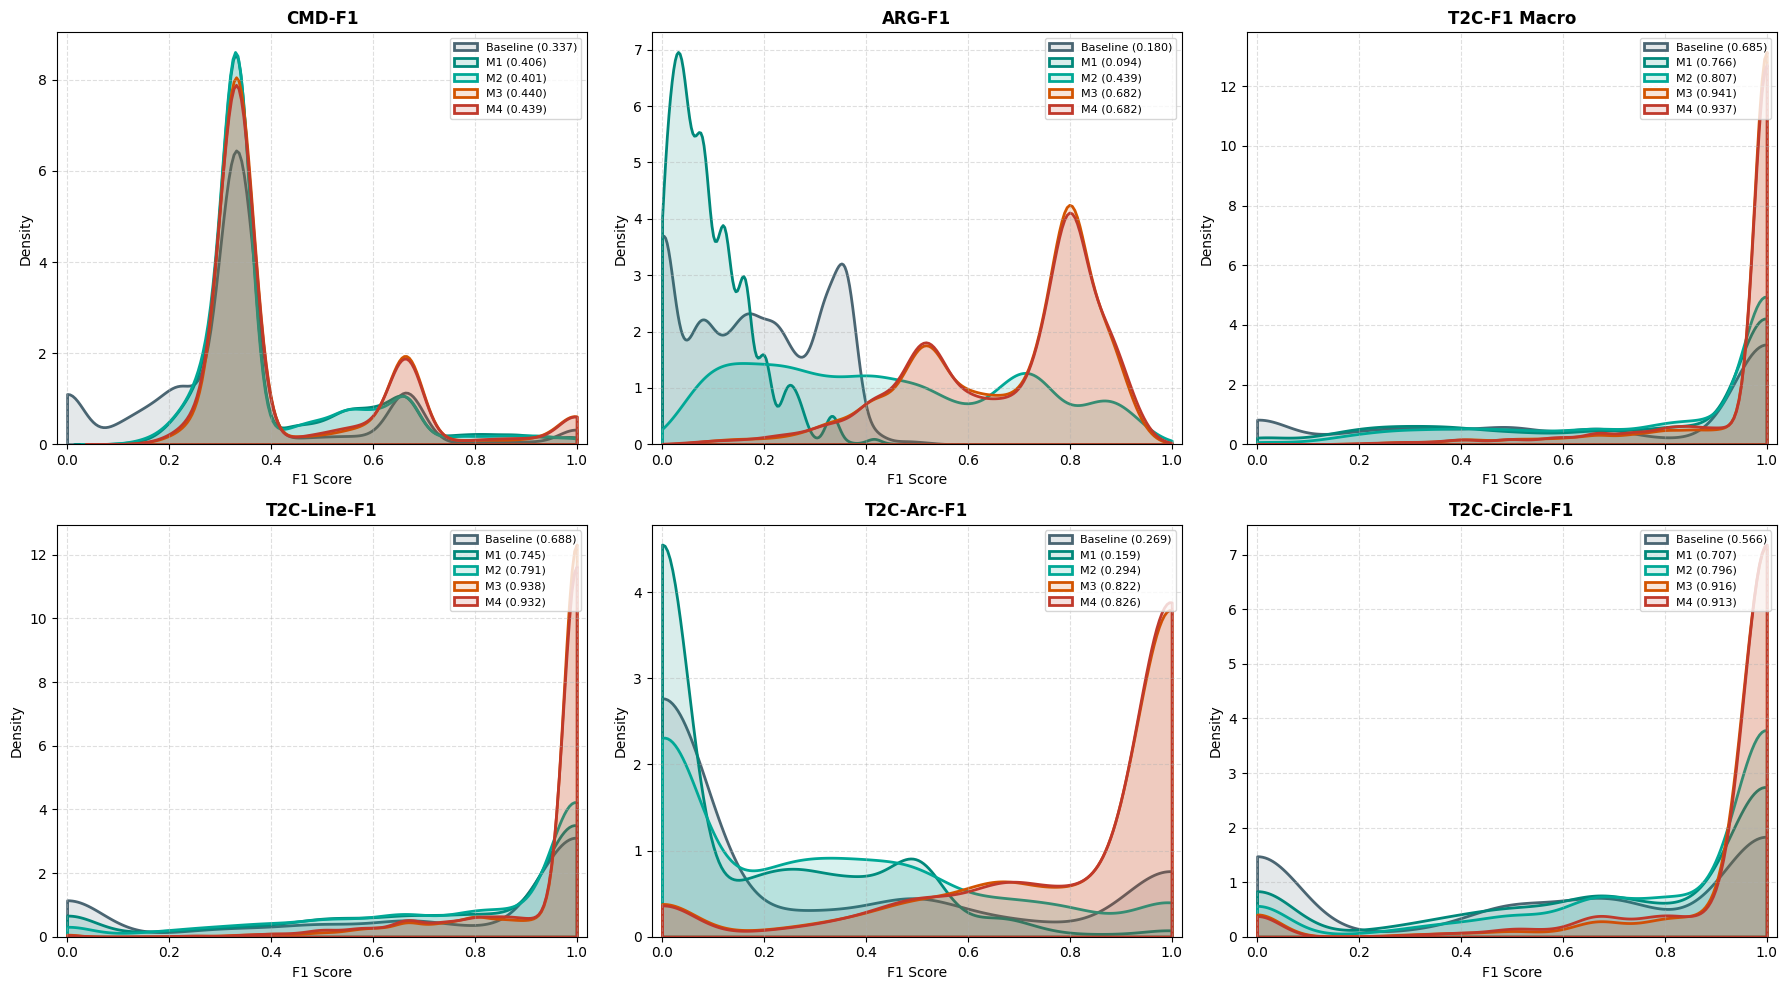

In [7]:
metrics_to_plot = [
    ("CMD-F1", "f1_cmd", None),
    ("ARG-F1", "f1_args", None),
    ("T2C-F1 Macro", "macro_f1", None),
    ("T2C-Line-F1", "line_f1", "gt_has_line"),
    ("T2C-Arc-F1", "arc_f1", "gt_has_arc"),
    ("T2C-Circle-F1", "circle_f1", "gt_has_circle"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (title, col_name, filter_col) in enumerate(metrics_to_plot):
    ax = axes[idx]
    for model_info in TARGET_MODELS:
        mid = model_info["id"]
        color = model_info["color"]
        df_m = test_eval_dfs[mid]
        
        data_series = df_m[col_name] if filter_col is None else df_m[df_m[filter_col]][col_name]
        vals = data_series.dropna().values
        mean_val = np.mean(vals) if len(vals) > 0 else 0.0
        
        if len(vals) > 0:
            if np.all(vals == vals[0]) or len(np.unique(vals)) <= 2:
                ax.hist(vals, bins=10, density=True, alpha=0.3, color=color, label=f"{mid} ({mean_val:.3f})")
            else:
                sns.kdeplot(vals, ax=ax, label=f"{mid} ({mean_val:.3f})", color=color, linewidth=2, fill=True, alpha=0.15, clip=(0.0, 1.0))
        
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("F1 Score", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(bottom=0.0)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(TEST_OUT_DIR, "test_kde_f1_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()


### Section 3: Test Chamfer Distance Evaluation

In [8]:
test_gt_pts_cache = {}
for ds in tqdm(test_samples, desc="Rendering GT Shapes (Test)"):
    uid = str(ds.uid)
    gt_shape = render_dual_seq_to_shape(ds.cmds, ds.args_dict)
    if gt_shape is not None:
        pts = sample_shape(gt_shape, n_u=20, n_v=20)
        test_gt_pts_cache[uid] = pts if len(pts) > 0 else None
    else:
        test_gt_pts_cache[uid] = None

test_cd_records = []
test_subset_cd_records = []
test_per_instance_cd = {}

for model_info in TARGET_MODELS:
    model_id = model_info["id"]
    cached_preds = test_predictions_cache[model_id]
    
    model_cds = []
    valid_count = 0
    invalid_count = 0
    
    pbar = tqdm(test_samples, desc=f"Computing CD for {model_id} (Test)")
    for ds in pbar:
        uid = str(ds.uid)
        pts_gt = test_gt_pts_cache.get(uid, None)
        
        pred_out = cached_preds.get(uid, None)
        pred_ds, _ = unify_model_prediction(pred_out, uid=uid)
        pred_cmds = pred_ds.cmds if pred_ds else []
        pred_args = pred_ds.args_dict if pred_ds else []
        
        pred_shape = render_dual_seq_to_shape(pred_cmds, pred_args) if pred_cmds else None
        
        cd_val = np.nan
        if pts_gt is not None and pred_shape is not None:
            try:
                pts_pred = sample_shape(pred_shape, n_u=20, n_v=20)
                if pts_pred is not None and len(pts_pred) > 0:
                    cd_val = chamfer_distance(pts_gt, pts_pred)
                    if not np.isnan(cd_val) and not np.isinf(cd_val):
                        valid_count += 1
                    else:
                        cd_val = np.nan
                        invalid_count += 1
                else:
                    invalid_count += 1
            except Exception:
                invalid_count += 1
        else:
            invalid_count += 1
            
        model_cds.append({
            "uid": uid,
            f"cd_{model_id}": cd_val,
            "gt_has_line": "LINE" in ds.cmds,
            "gt_has_arc": "ARC" in ds.cmds,
            "gt_has_circle": "CIRCLE" in ds.cmds,
        })
        
    df_cd_m = pd.DataFrame(model_cds)
    test_per_instance_cd[model_id] = df_cd_m
    
    # Overall metrics
    total_samples_n = len(test_samples)
    valid_cds = df_cd_m[f"cd_{model_id}"].dropna().values
    mean_cd = float(np.mean(valid_cds)) if len(valid_cds) > 0 else np.nan
    median_cd = float(np.median(valid_cds)) if len(valid_cds) > 0 else np.nan
    invalid_rate = float(invalid_count / total_samples_n) if total_samples_n > 0 else 0.0
    
    test_cd_records.append({
        "Model": model_id,
        "Mean CD": round(mean_cd, 5) if not np.isnan(mean_cd) else np.nan,
        "Median CD": round(median_cd, 5) if not np.isnan(median_cd) else np.nan,
        "Valid Reconstructions": len(valid_cds),
        "Total Samples": total_samples_n,
        "Invalid Ratio": round(invalid_rate, 4),
    })
    
    # Subsets: line only, line and arc only, line and circle
    subsets_def = [
        ("Line Only", df_cd_m[df_cd_m["gt_has_line"] & (~df_cd_m["gt_has_arc"]) & (~df_cd_m["gt_has_circle"])]),
        ("Line + Arc Only", df_cd_m[df_cd_m["gt_has_line"] & df_cd_m["gt_has_arc"] & (~df_cd_m["gt_has_circle"])]),
        ("Line + Circle", df_cd_m[df_cd_m["gt_has_line"] & df_cd_m["gt_has_circle"] & (~df_cd_m["gt_has_arc"])]),
    ]
    
    for s_name, s_df in subsets_def:
        s_total = len(s_df)
        s_valid = s_df[f"cd_{model_id}"].dropna().values
        s_mean_cd = float(np.mean(s_valid)) if len(s_valid) > 0 else np.nan
        s_median_cd = float(np.median(s_valid)) if len(s_valid) > 0 else np.nan
        s_invalid_rate = float((s_total - len(s_valid)) / s_total) if s_total > 0 else 0.0
        
        test_subset_cd_records.append({
            "Model": model_id,
            "Subset": s_name,
            "Total Samples": s_total,
            "Valid Count": len(s_valid),
            "Mean CD": round(s_mean_cd, 5) if not np.isnan(s_mean_cd) else np.nan,
            "Median CD": round(s_median_cd, 5) if not np.isnan(s_median_cd) else np.nan,
            "Invalid Ratio": round(s_invalid_rate, 4),
        })

df_test_cd_summary = pd.DataFrame(test_cd_records)
df_test_cd_summary.to_csv(os.path.join(TEST_OUT_DIR, "test_chamfer_distance_summary.csv"), index=False)
df_test_cd_summary.to_csv(os.path.join(BASE_OUT_DIR, "test_chamfer_distance_summary.csv"), index=False)

df_test_subset_cd = pd.DataFrame(test_subset_cd_records)
df_test_subset_cd.to_csv(os.path.join(TEST_OUT_DIR, "test_chamfer_distance_subsets_summary.csv"), index=False)
df_test_subset_cd.to_csv(os.path.join(BASE_OUT_DIR, "test_chamfer_distance_subsets_summary.csv"), index=False)

print("Test Chamfer Distance Summary:")
display(df_test_cd_summary)
print("Test Chamfer Distance Subsets Summary:")
display(df_test_subset_cd)

Rendering GT Shapes (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Computing CD for Baseline (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Computing CD for M1 (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Computing CD for M2 (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Computing CD for M3 (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Computing CD for M4 (Test):   0%|          | 0/8042 [00:00<?, ?it/s]

Test Chamfer Distance Summary:


,Model,Mean CD,Median CD,Valid Reconstructions,Total Samples,Invalid Ratio
0,Baseline,12.10174,12.32737,4297,8042,0.4657
1,M1,0.36059,0.34625,4701,8042,0.4154
2,M2,0.18545,0.11195,6639,8042,0.1745
3,M3,96.81877,0.00149,7166,8042,0.1089
4,M4,0.01554,0.00148,7182,8042,0.1069


Test Chamfer Distance Subsets Summary:


,Model,Subset,Total Samples,Valid Count,Mean CD,Median CD,Invalid Ratio
0,Baseline,Line Only,3990,2298,11.85127,12.18752,0.4241
1,Baseline,Line + Arc Only,728,236,12.08253,12.28380,0.6758
2,Baseline,Line + Circle,954,554,12.25379,12.35953,0.4193
3,M1,Line Only,3990,2123,0.37609,0.36221,0.4679
4,M1,Line + Arc Only,728,338,0.30964,0.28107,0.5357
5,M1,Line + Circle,954,727,0.31029,0.30085,0.2379
6,M2,Line Only,3990,3467,0.20486,0.12839,0.1311
7,M2,Line + Arc Only,728,262,0.29559,0.15270,0.6401
8,M2,Line + Circle,954,890,0.20059,0.12159,0.0671
9,M3,Line Only,3990,3925,0.01250,0.00123,0.0163


### Section 4: Test Permutation Tests

In [9]:
hypothesis_pairs = [
    ("Baseline", "M3"),
    ("M3", "M4"),
    ("Baseline", "M4"),
]

perm_records = []
metrics_list = ["CMD-F1", "ARG-F1", "T2C-F1", "Chamfer Distance", "Invalid Ratio"]

pbar = tqdm(total=len(hypothesis_pairs) * len(metrics_list), desc="Permutation Tests (Test)")

for m_a, m_b in hypothesis_pairs:
    df_a = test_eval_dfs[m_a]
    df_b = test_eval_dfs[m_b]
    merged_eval = pd.merge(df_a, df_b, on="uid", suffixes=("_A", "_B"))
    
    cd_a_df = test_per_instance_cd[m_a]
    cd_b_df = test_per_instance_cd[m_b]
    merged_cd = pd.merge(cd_a_df[["uid", f"cd_{m_a}"]], cd_b_df[["uid", f"cd_{m_b}"]], on="uid")
    
    for metric_label in metrics_list:
        if metric_label == "CMD-F1":
            vals_a = merged_eval["f1_cmd_A"].values
            vals_b = merged_eval["f1_cmd_B"].values
            stat_fn = paired_median_diff
            stat_a = float(np.median(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.median(vals_b)) if len(vals_b) > 0 else 0.0
        elif metric_label == "ARG-F1":
            vals_a = merged_eval["f1_args_A"].values
            vals_b = merged_eval["f1_args_B"].values
            stat_fn = paired_median_diff
            stat_a = float(np.median(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.median(vals_b)) if len(vals_b) > 0 else 0.0
        elif metric_label == "T2C-F1":
            t2c_col = "macro_f1" if "macro_f1_A" in merged_eval.columns else "t2c_macro_f1"
            vals_a = merged_eval[f"{t2c_col}_A"].values
            vals_b = merged_eval[f"{t2c_col}_B"].values
            stat_fn = paired_median_diff
            stat_a = float(np.median(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.median(vals_b)) if len(vals_b) > 0 else 0.0
        elif metric_label == "Chamfer Distance":
            cd_a_vals = merged_cd[f"cd_{m_a}"].values
            cd_b_vals = merged_cd[f"cd_{m_b}"].values
            valid_mask = np.isfinite(cd_a_vals) & np.isfinite(cd_b_vals)
            vals_a = cd_a_vals[valid_mask]
            vals_b = cd_b_vals[valid_mask]
            stat_fn = paired_median_diff
            stat_a = float(np.median(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.median(vals_b)) if len(vals_b) > 0 else 0.0
        elif metric_label == "Invalid Ratio":
            inv_a = (~np.isfinite(merged_cd[f"cd_{m_a}"])).astype(float).values
            inv_b = (~np.isfinite(merged_cd[f"cd_{m_b}"])).astype(float).values
            vals_a = inv_a
            vals_b = inv_b
            stat_fn = paired_mean_diff
            stat_a = float(np.mean(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.mean(vals_b)) if len(vals_b) > 0 else 0.0
            
        diff = stat_a - stat_b
        
        if len(vals_a) > 1 and not np.all(vals_a == vals_b):
            res = stats.permutation_test(
                data=(vals_a, vals_b),
                statistic=stat_fn,
                permutation_type="samples",
                n_resamples=10000,
                alternative="two-sided",
                random_state=42
            )
            p_val = float(res.pvalue)
        else:
            p_val = 1.0
            
        perm_records.append({
            "Metric": metric_label,
            "Model_A": m_a,
            "Model_B": m_b,
            "Median_A": round(stat_a, 4),
            "Median_B": round(stat_b, 4),
            "Median_Diff (A-B)": round(diff, 4),
            "p_value": p_val,
            "p_value_formatted": f"< 0.0001" if p_val < 0.0001 else f"{p_val:.4f}",
            "Significant (p < 0.05)": p_val < 0.05
        })
        pbar.update(1)

pbar.close()
df_perm = pd.DataFrame(perm_records)
df_perm.to_csv(os.path.join(TEST_OUT_DIR, "test_permutation_test_pvalues.csv"), index=False)
# Divide into three separate tables
df_test_b_vs_m3 = df_perm[(df_perm["Model_A"] == "Baseline") & (df_perm["Model_B"] == "M3")].copy()
df_test_m3_vs_m4 = df_perm[(df_perm["Model_A"] == "M3") & (df_perm["Model_B"] == "M4")].copy()
df_test_b_vs_m4 = df_perm[(df_perm["Model_A"] == "Baseline") & (df_perm["Model_B"] == "M4")].copy()

print("=== Table 1: Baseline vs M3 (Test) ===")
display(df_test_b_vs_m3)
print("=== Table 2: M3 vs M4 (Test) ===")
display(df_test_m3_vs_m4)
print("=== Table 3: Baseline vs M4 (Test) ===")
display(df_test_b_vs_m4)


Permutation Tests (Test):   0%|          | 0/15 [00:00<?, ?it/s]

,Metric,Model_A,Model_B,Median_A,Median_B,Median_Diff (A-B),p_value,p_value_formatted,Significant (p < 0.05)
0,CMD-F1,Baseline,M3,0.3333,0.3333,0.0000,1.000000,1.0000,False
1,ARG-F1,Baseline,M3,0.1765,0.7600,-0.5835,0.000200,0.0002,True
2,T2C-F1,Baseline,M3,1.0000,1.0000,0.0000,1.000000,1.0000,False
3,Chamfer Distance,Baseline,M3,12.3303,0.0014,12.3289,0.000200,0.0002,True
4,Invalid Ratio,Baseline,M3,0.4657,0.1089,0.3568,0.000200,0.0002,True
5,CMD-F1,M3,M4,0.3333,0.3333,0.0000,1.000000,1.0000,False
6,ARG-F1,M3,M4,0.7600,0.7600,0.0000,1.000000,1.0000,False
7,T2C-F1,M3,M4,1.0000,1.0000,0.0000,1.000000,1.0000,False
8,Chamfer Distance,M3,M4,0.0015,0.0015,0.0000,0.024598,0.0246,True
9,Invalid Ratio,M3,M4,0.1089,0.1069,0.0020,0.337766,0.3378,False


### Section 5: Test Top 50 Least/Most CD M4 Visualizations

In [10]:
if "M4" in test_per_instance_cd and "M4" in test_eval_dfs:
    df_m4_cd = pd.merge(test_eval_dfs["M4"], test_per_instance_cd["M4"], on="uid")
    df_m4_valid = df_m4_cd.dropna(subset=["cd_M4"]).sort_values(by="cd_M4").reset_index(drop=True)

    top_least = df_m4_valid.head(50)
    top_most = df_m4_valid.tail(50).iloc[::-1]
    sample_by_uid = {str(ds.uid): ds for ds in test_samples}

    test_least_dir = os.path.join(TEST_OUT_DIR, "visualizations/top50_least_cd")
    test_most_dir = os.path.join(TEST_OUT_DIR, "visualizations/top50_most_cd")

    for rank, (_, row) in enumerate(tqdm(top_least.iterrows(), total=len(top_least), desc="Test Least CD"), start=1):
        uid = str(row["uid"])
        m4_cd = float(row["cd_M4"])
        prompt = str(row.get("prompt", ""))
        gt_ds = sample_by_uid[uid]
        
        models_data = []
        for m_info in TARGET_MODELS:
            mid = m_info["id"]
            pred_out = test_predictions_cache[mid].get(uid, None)
            pred_ds, _ = unify_model_prediction(pred_out, uid=uid)
            p_cmds = pred_ds.cmds if pred_ds else []
            p_args = pred_ds.args_dict if pred_ds else []
            
            df_cd_curr = test_per_instance_cd[mid]
            cd_row = df_cd_curr[df_cd_curr["uid"] == uid]
            m_cd = float(cd_row[f"cd_{mid}"].iloc[0]) if not cd_row.empty and pd.notna(cd_row[f"cd_{mid}"].iloc[0]) else None
            models_data.append((mid, p_cmds, p_args, m_cd))
            
        uid_safe = uid.replace("/", "_")
        out_img = os.path.join(test_least_dir, f"{rank:02d}_{uid_safe}_cd_{m4_cd:.4f}.png")
        render_model_comparison_grid(models_data, gt_ds.cmds, gt_ds.args_dict, out_img, uid=uid, prompt_text=prompt, cell_size=(250, 250))

    for rank, (_, row) in enumerate(tqdm(top_most.iterrows(), total=len(top_most), desc="Test Most CD"), start=1):
        uid = str(row["uid"])
        m4_cd = float(row["cd_M4"])
        prompt = str(row.get("prompt", ""))
        gt_ds = sample_by_uid[uid]
        
        models_data = []
        for m_info in TARGET_MODELS:
            mid = m_info["id"]
            pred_out = test_predictions_cache[mid].get(uid, None)
            pred_ds, _ = unify_model_prediction(pred_out, uid=uid)
            p_cmds = pred_ds.cmds if pred_ds else []
            p_args = pred_ds.args_dict if pred_ds else []
            
            df_cd_curr = test_per_instance_cd[mid]
            cd_row = df_cd_curr[df_cd_curr["uid"] == uid]
            m_cd = float(cd_row[f"cd_{mid}"].iloc[0]) if not cd_row.empty and pd.notna(cd_row[f"cd_{mid}"].iloc[0]) else None
            models_data.append((mid, p_cmds, p_args, m_cd))
            
        uid_safe = uid.replace("/", "_")
        out_img = os.path.join(test_most_dir, f"{rank:02d}_{uid_safe}_cd_{m4_cd:.4f}.png")
        render_model_comparison_grid(models_data, gt_ds.cmds, gt_ds.args_dict, out_img, uid=uid, prompt_text=prompt, cell_size=(250, 250))


Test Least CD:   0%|          | 0/50 [00:00<?, ?it/s]

####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V3d_View created
Graphic3d_Camera created
Graphic3d_StructureManager created
Display3d class successfully initialized.
#########################################
OpenGl information:
  GLvendor: Mesa
  GLdevice: llvmpipe (LLVM 20.1.2, 256 bits)
  GLversion: 4.5 (Compatibility Profile) Mesa 25.2.8-0ubuntu0.24.04.2
  GLSLversion: 4.50
  Max texture size: 16384
  Max FBO dump size: 16384x16384
  Max combined texture units: 192
  Max MSAA samples: 4
  Viewport: 640x480
  Window buffer: RGB8 ALPHA0 DEPTH24 STENCIL8
  ResolutionRatio: 1
  FBO buffer: GL_SRGB8_ALPHA8 GL_DEPTH24_STENCIL8
####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V

Test Most CD:   0%|          | 0/50 [00:00<?, ?it/s]

####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V3d_View created
Graphic3d_Camera created
Graphic3d_StructureManager created
Display3d class successfully initialized.
#########################################
OpenGl information:
  GLvendor: Mesa
  GLdevice: llvmpipe (LLVM 20.1.2, 256 bits)
  GLversion: 4.5 (Compatibility Profile) Mesa 25.2.8-0ubuntu0.24.04.2
  GLSLversion: 4.50
  Max texture size: 16384
  Max FBO dump size: 16384x16384
  Max combined texture units: 192
  Max MSAA samples: 4
  Viewport: 640x480
  Window buffer: RGB8 ALPHA0 DEPTH24 STENCIL8
  ResolutionRatio: 1
  FBO buffer: GL_SRGB8_ALPHA8 GL_DEPTH24_STENCIL8
####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V

# PART 2: VALIDATION SET EVALUATION

### Load

In [11]:
all_val_samples = load_val_data(
    data_folder=base_cfg.data.data_folder,
    metadata_csv=base_cfg.data.metadata_csv,
    split_json=base_cfg.data.split_json
)
val_samples = all_val_samples[:EVAL_MAX_SAMPLES] if EVAL_MAX_SAMPLES is not None else all_val_samples


Loading CSV from: /home/alief/prjkcad/data/text2cad/text2cad_v1.1.csv
Processing 8925 rows to load JSON payloads...


100%|██████████| 8925/8925 [00:00<00:00, 20578.94it/s]


Successfully created 8921/8925 DualSeq instances.


### Section 6: Validation Metric Evaluation

In [12]:
val_predictions_cache = {}
val_eval_dfs = {}
val_summary_records = []

for model_info in TARGET_MODELS:
    model_id = model_info["id"]
    folder = model_info["folder"]
    pred_path = resolve_cache_path(os.path.join(INPUT_CACHE_DIR, folder), "val")
    cached_preds = validate_and_load_cache(pred_path, val_samples, model_id, "val")
    val_predictions_cache[model_id] = cached_preds
    
    per_instance_records = []
    all_model_arc_errors_val = []
    all_model_arg_errors_val = []
    
    pbar = tqdm(val_samples, desc=f"Evaluating {model_id} (Val)")
    for ds in pbar:
        uid = str(ds.uid)
        gt_cmds = ds.cmds
        gt_args = ds.args_dict
        gt_json = ds.json_object if hasattr(ds, "json_object") else {}
        
        pred_out = cached_preds.get(uid, None)
        pred_ds, pred_cad = unify_model_prediction(pred_out, uid=uid)
        
        pred_cmds = pred_ds.cmds if pred_ds is not None else []
        pred_args = pred_ds.args_dict if pred_ds is not None else []
        
        cmd_m = eval_cmd_only(pred_cmds, gt_cmds)
        f1_cmd = float(cmd_m.get("eval/avg_f1", 0.0))
        
        arg_metrics = evaluate_args_and_token_error(pred_cmds, pred_args, gt_cmds, gt_args, metadata=DUAL_SEQ_METADATA)
        f1_args = arg_metrics["f1_args"]
        acc_args = arg_metrics["acc_args"]
        all_model_arc_errors_val.extend(arg_metrics["arc_token_errors"])
        all_model_arg_errors_val.extend(arg_metrics["arg_token_errors"])
        
        macro_f1 = 0.0
        line_f1 = np.nan
        arc_f1 = np.nan
        circle_f1 = np.nan
        extrude_f1 = np.nan
        
        try:
            gt_cad = CADSequence.from_minimal_json(gt_json) if gt_json else dualseq_to_cadseq(gt_cmds, gt_args)
            if gt_cad is not None and pred_cad is not None:
                report_df, _ = gt_cad.generate_report(pred_cad, uid)
                if report_df is not None and not report_df.empty:
                    macro_f1 = float(report_df["macro_f1"].iloc[0])
                    
                    # Average over instances containing at least 1 of the command
                    n_line_gt = int(report_df["line_total_gt"].iloc[0]) if "line_total_gt" in report_df.columns else 0
                    if gt_has_line or n_line_gt > 0:
                        line_f1 = float(report_df["line_f1"].iloc[0])
                        
                    n_arc_gt = int(report_df["arc_total_gt"].iloc[0]) if "arc_total_gt" in report_df.columns else 0
                    if gt_has_arc or n_arc_gt > 0:
                        arc_f1 = float(report_df["arc_f1"].iloc[0])
                        
                    n_circle_gt = int(report_df["circle_total_gt"].iloc[0]) if "circle_total_gt" in report_df.columns else 0
                    if gt_has_circle or n_circle_gt > 0:
                        circle_f1 = float(report_df["circle_f1"].iloc[0])
                        
                    num_ext_gt = float(report_df["num_ext_gt"].iloc[0]) if "num_ext_gt" in report_df.columns else 0.0
                    has_extrude = any(c.startswith("EXTRUDE_") for c in gt_cmds) or (num_ext_gt > 0)
                    if has_extrude:
                        b_matches = float(report_df["b"].iloc[0]) if "b" in report_df.columns else 0.0
                        num_ext_pred = float(report_df["num_ext_pred"].iloc[0]) if "num_ext_pred" in report_df.columns else 0.0
                        prec_ext = b_matches / max(num_ext_pred, 1.0)
                        rec_ext = b_matches / max(num_ext_gt, 1.0)
                        extrude_f1 = 2.0 * prec_ext * rec_ext / (prec_ext + rec_ext) if (prec_ext + rec_ext) > 0 else 0.0
        except Exception:
            pass
        
        gt_has_line = "LINE" in gt_cmds
        gt_has_arc = "ARC" in gt_cmds
        gt_has_circle = "CIRCLE" in gt_cmds
        
        per_instance_records.append({
            "uid": uid,
            "prompt": getattr(ds, "prompt", ""),
            "f1_cmd": f1_cmd,
            "f1_args": f1_args,
            "acc_args": acc_args,
            "macro_f1": macro_f1,
            "line_f1": line_f1,
            "arc_f1": arc_f1,
            "circle_f1": circle_f1,
            "extrude_f1": extrude_f1,
            "mean_arc_token_err": arg_metrics["mean_arc_token_err"],
            "median_arc_token_err": arg_metrics["median_arc_token_err"],
            "mean_arg_token_err": arg_metrics["mean_arg_token_err"],
            "median_arg_token_err": arg_metrics["median_arg_token_err"],
            "gt_has_line": gt_has_line,
            "gt_has_arc": gt_has_arc,
            "gt_has_circle": gt_has_circle,
        })
        
    df_eval = pd.DataFrame(per_instance_records)
    val_eval_dfs[model_id] = df_eval
    
    line_subset = df_eval[df_eval["gt_has_line"]]
    arc_subset = df_eval[df_eval["gt_has_arc"]]
    circle_subset = df_eval[df_eval["gt_has_circle"]]
    
    overall_mean_arc_err_val = float(np.mean(all_model_arc_errors_val)) if all_model_arc_errors_val else np.nan
    overall_median_arc_err_val = float(np.median(all_model_arc_errors_val)) if all_model_arc_errors_val else np.nan
    overall_mean_arg_err_val = float(np.mean(all_model_arg_errors_val)) if all_model_arg_errors_val else np.nan
    overall_median_arg_err_val = float(np.median(all_model_arg_errors_val)) if all_model_arg_errors_val else np.nan
    
    val_summary_records.append({
        "Model": model_id,
        "CMD-F1": round(df_eval["f1_cmd"].mean(), 4),
        "ARG-F1": round(df_eval["f1_args"].mean(), 4),
        "ARG-Acc": round(df_eval["acc_args"].mean(), 4),
        "T2C-F1": round(df_eval["macro_f1"].mean(), 4),
        "T2C-Line-F1": round(df_eval["line_f1"].dropna().mean(), 4) if not df_eval["line_f1"].dropna().empty else 0.0,
        "T2C-Arc-F1": round(df_eval["arc_f1"].dropna().mean(), 4) if not df_eval["arc_f1"].dropna().empty else 0.0,
        "T2C-Circle-F1": round(df_eval["circle_f1"].dropna().mean(), 4) if not df_eval["circle_f1"].dropna().empty else 0.0,
        "T2C-Extrude-F1": round(df_eval["extrude_f1"].dropna().mean(), 4) if not df_eval["extrude_f1"].dropna().empty else 0.0,
        "Mean-Arc-Token-Error": round(overall_mean_arc_err_val, 2) if not np.isnan(overall_mean_arc_err_val) else np.nan,
        "Median-Arc-Token-Error": round(overall_median_arc_err_val, 2) if not np.isnan(overall_median_arc_err_val) else np.nan,
        "Mean-ARG-Token-Error": round(overall_mean_arg_err_val, 2) if not np.isnan(overall_mean_arg_err_val) else np.nan,
        "Median-ARG-Token-Error": round(overall_median_arg_err_val, 2) if not np.isnan(overall_median_arg_err_val) else np.nan,
        "Cached Samples": len(cached_preds),
        "Evaluated Samples": len(df_eval),
    })

df_val_summary = pd.DataFrame(val_summary_records)
df_val_summary.to_csv(os.path.join(VAL_OUT_DIR, "val_evaluation_summary.csv"), index=False)
df_val_summary.to_csv(os.path.join(BASE_OUT_DIR, "all_5_models_val_evaluation_summary.csv"), index=False)
df_val_summary

Evaluating Baseline (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Evaluating M1 (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Evaluating M2 (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Evaluating M3 (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Evaluating M4 (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

,Model,CMD-F1,ARG-F1,ARG-Acc,T2C-F1,T2C-Line-F1,T2C-Arc-F1,T2C-Circle-F1,T2C-Extrude-F1,Mean-Arc-Token-Error,Median-Arc-Token-Error,Mean-ARG-Token-Error,Median-ARG-Token-Error,Cached Samples,Evaluated Samples
0,Baseline,0.3391,0.1855,0.1761,0.6873,0.5603,0.1427,0.3648,0.0000,18.69,12.0,25.01,13.0,8921,8921
1,M1,0.4070,0.1048,0.1054,0.7652,0.6078,0.0935,0.4505,0.8867,16.92,9.0,11.13,3.0,8921,8921
2,M2,0.4014,0.4477,0.4471,0.8087,0.6496,0.1680,0.5066,0.8948,13.47,8.0,7.51,0.0,8921,8921
3,M3,0.4405,0.6817,0.6778,0.9413,0.7698,0.4565,0.5813,0.9516,1.58,0.0,1.04,0.0,8921,8921
4,M4,0.4395,0.6817,0.6845,0.9378,0.7658,0.4603,0.5800,0.9440,1.12,0.0,1.02,0.0,8921,8921


### Section 7: Validation Metric KDE Plots

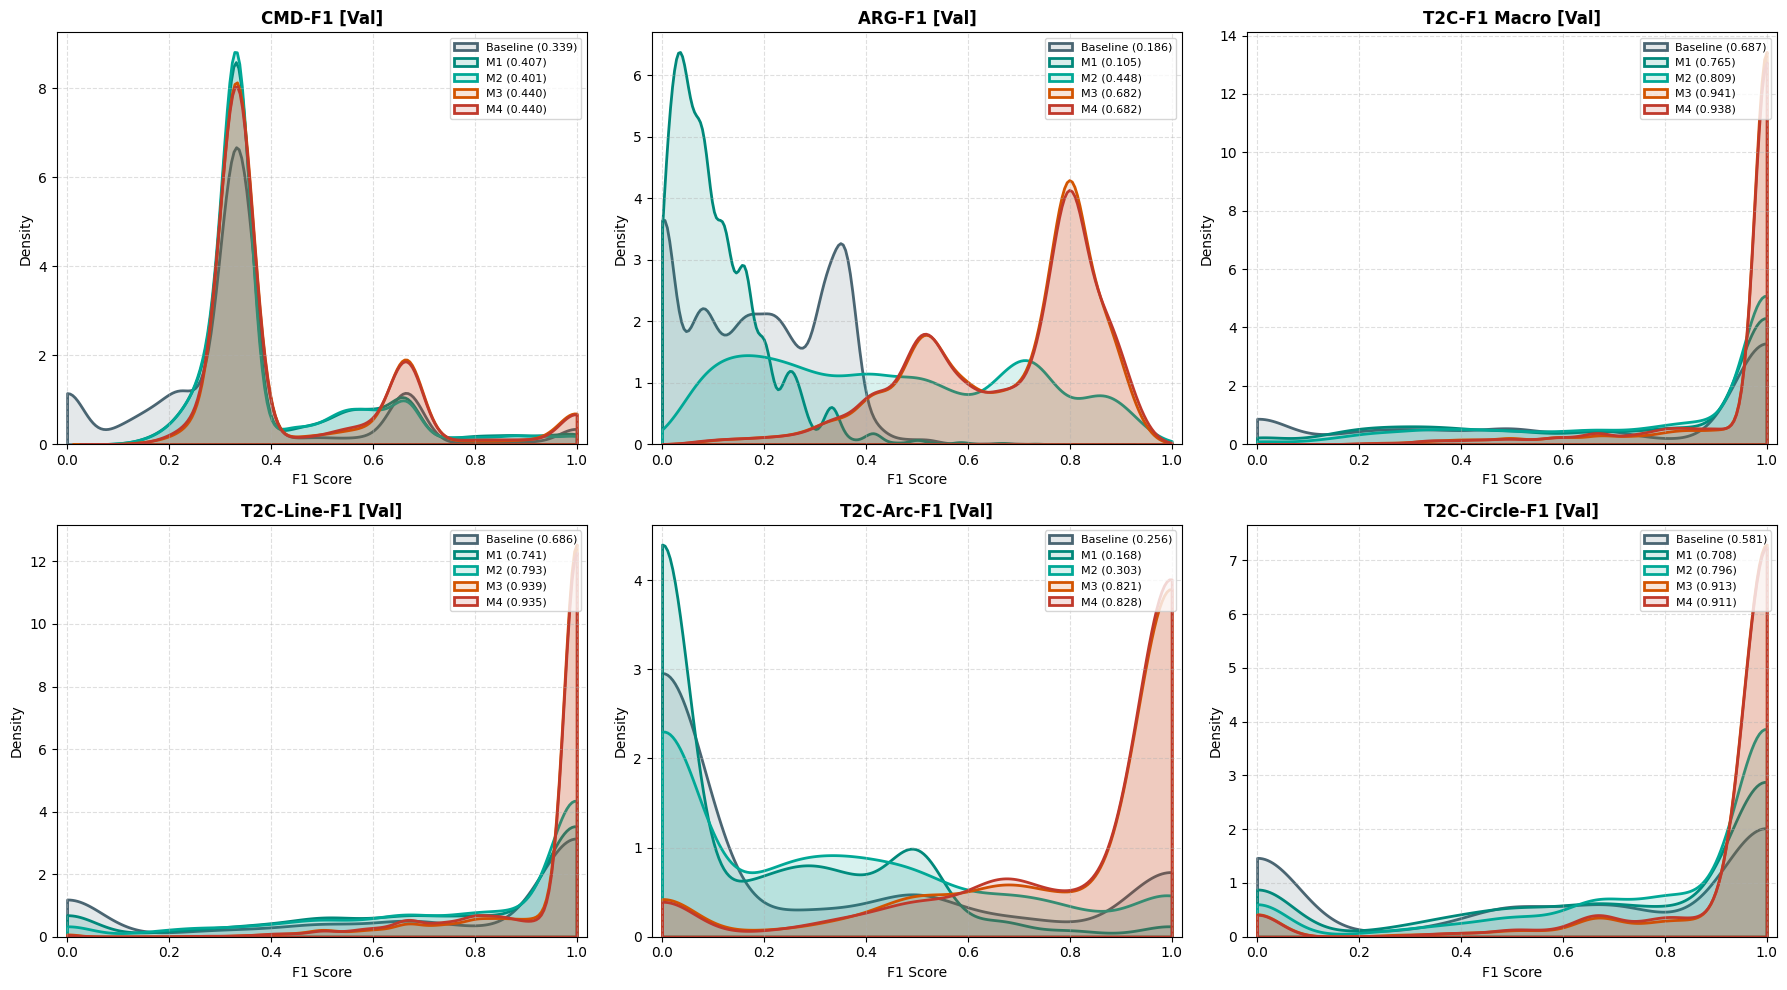

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (title, col_name, filter_col) in enumerate(metrics_to_plot):
    ax = axes[idx]
    for model_info in TARGET_MODELS:
        mid = model_info["id"]
        color = model_info["color"]
        df_m = val_eval_dfs[mid]
        
        data_series = df_m[col_name] if filter_col is None else df_m[df_m[filter_col]][col_name]
        vals = data_series.dropna().values
        mean_val = np.mean(vals) if len(vals) > 0 else 0.0
        
        if len(vals) > 0:
            if np.all(vals == vals[0]) or len(np.unique(vals)) <= 2:
                ax.hist(vals, bins=10, density=True, alpha=0.3, color=color, label=f"{mid} ({mean_val:.3f})")
            else:
                sns.kdeplot(vals, ax=ax, label=f"{mid} ({mean_val:.3f})", color=color, linewidth=2, fill=True, alpha=0.15, clip=(0.0, 1.0))
        
    ax.set_title(f"{title} [Val]", fontsize=12, fontweight="bold")
    ax.set_xlabel("F1 Score", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(bottom=0.0)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(VAL_OUT_DIR, "val_kde_f1_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()


### Section 8: Validation Chamfer Distance Evaluation

In [14]:
val_gt_pts_cache = {}
for ds in tqdm(val_samples, desc="Rendering GT Shapes (Val)"):
    uid = str(ds.uid)
    gt_shape = render_dual_seq_to_shape(ds.cmds, ds.args_dict)
    if gt_shape is not None:
        pts = sample_shape(gt_shape, n_u=20, n_v=20)
        val_gt_pts_cache[uid] = pts if len(pts) > 0 else None
    else:
        val_gt_pts_cache[uid] = None

val_cd_records = []
val_subset_cd_records = []
val_per_instance_cd = {}

for model_info in TARGET_MODELS:
    model_id = model_info["id"]
    cached_preds = val_predictions_cache[model_id]
    
    model_cds = []
    valid_count = 0
    invalid_count = 0
    
    pbar = tqdm(val_samples, desc=f"Computing CD for {model_id} (Val)")
    for ds in pbar:
        uid = str(ds.uid)
        pts_gt = val_gt_pts_cache.get(uid, None)
        
        pred_out = cached_preds.get(uid, None)
        pred_ds, _ = unify_model_prediction(pred_out, uid=uid)
        pred_cmds = pred_ds.cmds if pred_ds else []
        pred_args = pred_ds.args_dict if pred_ds else []
        
        pred_shape = render_dual_seq_to_shape(pred_cmds, pred_args) if pred_cmds else None
        
        cd_val = np.nan
        if pts_gt is not None and pred_shape is not None:
            try:
                pts_pred = sample_shape(pred_shape, n_u=20, n_v=20)
                if pts_pred is not None and len(pts_pred) > 0:
                    cd_val = chamfer_distance(pts_gt, pts_pred)
                    if not np.isnan(cd_val) and not np.isinf(cd_val):
                        valid_count += 1
                    else:
                        cd_val = np.nan
                        invalid_count += 1
                else:
                    invalid_count += 1
            except Exception:
                invalid_count += 1
        else:
            invalid_count += 1
            
        model_cds.append({
            "uid": uid,
            f"cd_{model_id}": cd_val,
            "gt_has_line": "LINE" in ds.cmds,
            "gt_has_arc": "ARC" in ds.cmds,
            "gt_has_circle": "CIRCLE" in ds.cmds,
        })
        
    df_cd_m = pd.DataFrame(model_cds)
    val_per_instance_cd[model_id] = df_cd_m
    
    total_samples_n = len(val_samples)
    valid_cds = df_cd_m[f"cd_{model_id}"].dropna().values
    mean_cd = float(np.mean(valid_cds)) if len(valid_cds) > 0 else np.nan
    median_cd = float(np.median(valid_cds)) if len(valid_cds) > 0 else np.nan
    invalid_rate = float(invalid_count / total_samples_n) if total_samples_n > 0 else 0.0
    
    val_cd_records.append({
        "Model": model_id,
        "Mean CD": round(mean_cd, 5) if not np.isnan(mean_cd) else np.nan,
        "Median CD": round(median_cd, 5) if not np.isnan(median_cd) else np.nan,
        "Valid Reconstructions": len(valid_cds),
        "Total Samples": total_samples_n,
        "Invalid Ratio": round(invalid_rate, 4),
    })
    
    # Subsets
    subsets_def = [
        ("Line Only", df_cd_m[df_cd_m["gt_has_line"] & (~df_cd_m["gt_has_arc"]) & (~df_cd_m["gt_has_circle"])]),
        ("Line + Arc Only", df_cd_m[df_cd_m["gt_has_line"] & df_cd_m["gt_has_arc"] & (~df_cd_m["gt_has_circle"])]),
        ("Line + Circle", df_cd_m[df_cd_m["gt_has_line"] & df_cd_m["gt_has_circle"] & (~df_cd_m["gt_has_arc"])]),
    ]
    
    for s_name, s_df in subsets_def:
        s_total = len(s_df)
        s_valid = s_df[f"cd_{model_id}"].dropna().values
        s_mean_cd = float(np.mean(s_valid)) if len(s_valid) > 0 else np.nan
        s_median_cd = float(np.median(s_valid)) if len(s_valid) > 0 else np.nan
        s_invalid_rate = float((s_total - len(s_valid)) / s_total) if s_total > 0 else 0.0
        
        val_subset_cd_records.append({
            "Model": model_id,
            "Subset": s_name,
            "Total Samples": s_total,
            "Valid Count": len(s_valid),
            "Mean CD": round(s_mean_cd, 5) if not np.isnan(s_mean_cd) else np.nan,
            "Median CD": round(s_median_cd, 5) if not np.isnan(s_median_cd) else np.nan,
            "Invalid Ratio": round(s_invalid_rate, 4),
        })

df_val_cd_summary = pd.DataFrame(val_cd_records)
df_val_cd_summary.to_csv(os.path.join(VAL_OUT_DIR, "val_chamfer_distance_summary.csv"), index=False)
df_val_cd_summary.to_csv(os.path.join(BASE_OUT_DIR, "val_chamfer_distance_summary.csv"), index=False)

df_val_subset_cd = pd.DataFrame(val_subset_cd_records)
df_val_subset_cd.to_csv(os.path.join(VAL_OUT_DIR, "val_chamfer_distance_subsets_summary.csv"), index=False)
df_val_subset_cd.to_csv(os.path.join(BASE_OUT_DIR, "val_chamfer_distance_subsets_summary.csv"), index=False)

print("Validation Chamfer Distance Summary:")
display(df_val_cd_summary)
print("Validation Chamfer Distance Subsets Summary:")
display(df_val_subset_cd)

Rendering GT Shapes (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Computing CD for Baseline (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Computing CD for M1 (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Computing CD for M2 (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Computing CD for M3 (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Computing CD for M4 (Val):   0%|          | 0/8921 [00:00<?, ?it/s]

Validation Chamfer Distance Summary:


,Model,Mean CD,Median CD,Valid Reconstructions,Total Samples,Invalid Ratio
0,Baseline,11.99954,12.22421,4760,8921,0.4664
1,M1,0.34590,0.33539,5234,8921,0.4133
2,M2,2.84463,0.11413,7393,8921,0.1713
3,M3,232.60097,0.00142,7827,8921,0.1226
4,M4,867.51233,0.00141,7865,8921,0.1184


Validation Chamfer Distance Subsets Summary:


,Model,Subset,Total Samples,Valid Count,Mean CD,Median CD,Invalid Ratio
0,Baseline,Line Only,4297,2452,11.77774,12.10944,0.4294
1,Baseline,Line + Arc Only,802,213,11.98252,12.26262,0.7344
2,Baseline,Line + Circle,1027,594,12.29323,12.41630,0.4216
3,M1,Line Only,4297,2298,0.37479,0.35786,0.4652
4,M1,Line + Arc Only,802,419,0.30728,0.28155,0.4776
5,M1,Line + Circle,1027,765,0.30612,0.29578,0.2551
6,M2,Line Only,4297,3751,0.21877,0.13883,0.1271
7,M2,Line + Arc Only,802,293,67.24990,0.15829,0.6347
8,M2,Line + Circle,1027,967,0.19643,0.12610,0.0584
9,M3,Line Only,4297,4133,0.01452,0.00121,0.0382


### Section 9: Validation Permutation Tests

In [15]:
val_perm_records = []
pbar = tqdm(total=len(hypothesis_pairs) * len(metrics_list), desc="Permutation Tests (Val)")

for m_a, m_b in hypothesis_pairs:
    df_a = val_eval_dfs[m_a]
    df_b = val_eval_dfs[m_b]
    merged_eval = pd.merge(df_a, df_b, on="uid", suffixes=("_A", "_B"))
    
    cd_a_df = val_per_instance_cd[m_a]
    cd_b_df = val_per_instance_cd[m_b]
    merged_cd = pd.merge(cd_a_df[["uid", f"cd_{m_a}"]], cd_b_df[["uid", f"cd_{m_b}"]], on="uid")
    
    for metric_label in metrics_list:
        if metric_label == "CMD-F1":
            vals_a = merged_eval["f1_cmd_A"].values
            vals_b = merged_eval["f1_cmd_B"].values
            stat_fn = paired_median_diff
            stat_a = float(np.median(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.median(vals_b)) if len(vals_b) > 0 else 0.0
        elif metric_label == "ARG-F1":
            vals_a = merged_eval["f1_args_A"].values
            vals_b = merged_eval["f1_args_B"].values
            stat_fn = paired_median_diff
            stat_a = float(np.median(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.median(vals_b)) if len(vals_b) > 0 else 0.0
        elif metric_label == "T2C-F1":
            t2c_col = "macro_f1" if "macro_f1_A" in merged_eval.columns else "t2c_macro_f1"
            vals_a = merged_eval[f"{t2c_col}_A"].values
            vals_b = merged_eval[f"{t2c_col}_B"].values
            stat_fn = paired_median_diff
            stat_a = float(np.median(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.median(vals_b)) if len(vals_b) > 0 else 0.0
        elif metric_label == "Chamfer Distance":
            cd_a_vals = merged_cd[f"cd_{m_a}"].values
            cd_b_vals = merged_cd[f"cd_{m_b}"].values
            valid_mask = np.isfinite(cd_a_vals) & np.isfinite(cd_b_vals)
            vals_a = cd_a_vals[valid_mask]
            vals_b = cd_b_vals[valid_mask]
            stat_fn = paired_median_diff
            stat_a = float(np.median(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.median(vals_b)) if len(vals_b) > 0 else 0.0
        elif metric_label == "Invalid Ratio":
            inv_a = (~np.isfinite(merged_cd[f"cd_{m_a}"])).astype(float).values
            inv_b = (~np.isfinite(merged_cd[f"cd_{m_b}"])).astype(float).values
            vals_a = inv_a
            vals_b = inv_b
            stat_fn = paired_mean_diff
            stat_a = float(np.mean(vals_a)) if len(vals_a) > 0 else 0.0
            stat_b = float(np.mean(vals_b)) if len(vals_b) > 0 else 0.0
            
        diff = stat_a - stat_b
        
        if len(vals_a) > 1 and not np.all(vals_a == vals_b):
            res = stats.permutation_test(
                data=(vals_a, vals_b),
                statistic=stat_fn,
                permutation_type="samples",
                n_resamples=10000,
                alternative="two-sided",
                random_state=42
            )
            p_val = float(res.pvalue)
        else:
            p_val = 1.0
            
        val_perm_records.append({
            "Metric": metric_label,
            "Model_A": m_a,
            "Model_B": m_b,
            "Median_A": round(stat_a, 4),
            "Median_B": round(stat_b, 4),
            "Median_Diff (A-B)": round(diff, 4),
            "p_value": p_val,
            "p_value_formatted": f"< 0.0001" if p_val < 0.0001 else f"{p_val:.4f}",
            "Significant (p < 0.05)": p_val < 0.05
        })
        pbar.update(1)

pbar.close()
df_val_perm = pd.DataFrame(val_perm_records)
df_val_perm.to_csv(os.path.join(VAL_OUT_DIR, "val_permutation_test_pvalues.csv"), index=False)
# Divide into three separate tables
df_val_b_vs_m3 = df_val_perm[(df_val_perm["Model_A"] == "Baseline") & (df_val_perm["Model_B"] == "M3")].copy()
df_val_m3_vs_m4 = df_val_perm[(df_val_perm["Model_A"] == "M3") & (df_val_perm["Model_B"] == "M4")].copy()
df_val_b_vs_m4 = df_val_perm[(df_val_perm["Model_A"] == "Baseline") & (df_val_perm["Model_B"] == "M4")].copy()

print("=== Table 1: Baseline vs M3 (Val) ===")
display(df_val_b_vs_m3)
print("=== Table 2: M3 vs M4 (Val) ===")
display(df_val_m3_vs_m4)
print("=== Table 3: Baseline vs M4 (Val) ===")
display(df_val_b_vs_m4)


Permutation Tests (Val):   0%|          | 0/15 [00:00<?, ?it/s]

,Metric,Model_A,Model_B,Median_A,Median_B,Median_Diff (A-B),p_value,p_value_formatted,Significant (p < 0.05)
0,CMD-F1,Baseline,M3,0.3333,0.3333,0.0000,1.000000,1.0000,False
1,ARG-F1,Baseline,M3,0.1837,0.7600,-0.5763,0.000200,0.0002,True
2,T2C-F1,Baseline,M3,1.0000,1.0000,0.0000,1.000000,1.0000,False
3,Chamfer Distance,Baseline,M3,12.2149,0.0013,12.2136,0.000200,0.0002,True
4,Invalid Ratio,Baseline,M3,0.4664,0.1226,0.3438,0.000200,0.0002,True
5,CMD-F1,M3,M4,0.3333,0.3333,0.0000,1.000000,1.0000,False
6,ARG-F1,M3,M4,0.7600,0.7600,0.0000,1.000000,1.0000,False
7,T2C-F1,M3,M4,1.0000,1.0000,0.0000,1.000000,1.0000,False
8,Chamfer Distance,M3,M4,0.0014,0.0014,0.0000,0.053995,0.0540,False
9,Invalid Ratio,M3,M4,0.1226,0.1184,0.0043,0.016798,0.0168,True


### Section 10: Validation Top 50 Least/Most CD M4 Visualizations

In [16]:
if "M4" in val_per_instance_cd and "M4" in val_eval_dfs:
    df_m4_cd_val = pd.merge(val_eval_dfs["M4"], val_per_instance_cd["M4"], on="uid")
    df_m4_valid_val = df_m4_cd_val.dropna(subset=["cd_M4"]).sort_values(by="cd_M4").reset_index(drop=True)

    top_least_val = df_m4_valid_val.head(50)
    top_most_val = df_m4_valid_val.tail(50).iloc[::-1]
    val_sample_by_uid = {str(ds.uid): ds for ds in val_samples}

    val_least_dir = os.path.join(VAL_OUT_DIR, "visualizations/top50_least_cd")
    val_most_dir = os.path.join(VAL_OUT_DIR, "visualizations/top50_most_cd")

    for rank, (_, row) in enumerate(tqdm(top_least_val.iterrows(), total=len(top_least_val), desc="Val Least CD"), start=1):
        uid = str(row["uid"])
        m4_cd = float(row["cd_M4"])
        prompt = str(row.get("prompt", ""))
        gt_ds = val_sample_by_uid[uid]
        
        models_data = []
        for m_info in TARGET_MODELS:
            mid = m_info["id"]
            pred_out = val_predictions_cache[mid].get(uid, None)
            pred_ds, _ = unify_model_prediction(pred_out, uid=uid)
            p_cmds = pred_ds.cmds if pred_ds else []
            p_args = pred_ds.args_dict if pred_ds else []
            
            df_cd_curr = val_per_instance_cd[mid]
            cd_row = df_cd_curr[df_cd_curr["uid"] == uid]
            m_cd = float(cd_row[f"cd_{mid}"].iloc[0]) if not cd_row.empty and pd.notna(cd_row[f"cd_{mid}"].iloc[0]) else None
            models_data.append((mid, p_cmds, p_args, m_cd))
            
        uid_safe = uid.replace("/", "_")
        out_img = os.path.join(val_least_dir, f"{rank:02d}_{uid_safe}_cd_{m4_cd:.4f}.png")
        render_model_comparison_grid(models_data, gt_ds.cmds, gt_ds.args_dict, out_img, uid=uid, prompt_text=prompt, cell_size=(250, 250))

    for rank, (_, row) in enumerate(tqdm(top_most_val.iterrows(), total=len(top_most_val), desc="Val Most CD"), start=1):
        uid = str(row["uid"])
        m4_cd = float(row["cd_M4"])
        prompt = str(row.get("prompt", ""))
        gt_ds = val_sample_by_uid[uid]
        
        models_data = []
        for m_info in TARGET_MODELS:
            mid = m_info["id"]
            pred_out = val_predictions_cache[mid].get(uid, None)
            pred_ds, _ = unify_model_prediction(pred_out, uid=uid)
            p_cmds = pred_ds.cmds if pred_ds else []
            p_args = pred_ds.args_dict if pred_ds else []
            
            df_cd_curr = val_per_instance_cd[mid]
            cd_row = df_cd_curr[df_cd_curr["uid"] == uid]
            m_cd = float(cd_row[f"cd_{mid}"].iloc[0]) if not cd_row.empty and pd.notna(cd_row[f"cd_{mid}"].iloc[0]) else None
            models_data.append((mid, p_cmds, p_args, m_cd))
            
        uid_safe = uid.replace("/", "_")
        out_img = os.path.join(val_most_dir, f"{rank:02d}_{uid_safe}_cd_{m4_cd:.4f}.png")
        render_model_comparison_grid(models_data, gt_ds.cmds, gt_ds.args_dict, out_img, uid=uid, prompt_text=prompt, cell_size=(250, 250))


Val Least CD:   0%|          | 0/50 [00:00<?, ?it/s]

####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V3d_View created
Graphic3d_Camera created
Graphic3d_StructureManager created
Display3d class successfully initialized.
#########################################
OpenGl information:
  GLvendor: Mesa
  GLdevice: llvmpipe (LLVM 20.1.2, 256 bits)
  GLversion: 4.5 (Compatibility Profile) Mesa 25.2.8-0ubuntu0.24.04.2
  GLSLversion: 4.50
  Max texture size: 16384
  Max FBO dump size: 16384x16384
  Max combined texture units: 192
  Max MSAA samples: 4
  Viewport: 640x480
  Window buffer: RGB8 ALPHA0 DEPTH24 STENCIL8
  ResolutionRatio: 1
  FBO buffer: GL_SRGB8_ALPHA8 GL_DEPTH24_STENCIL8
####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V

Val Most CD:   0%|          | 0/50 [00:00<?, ?it/s]

####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V3d_View created
Graphic3d_Camera created
Graphic3d_StructureManager created
Display3d class successfully initialized.
#########################################
OpenGl information:
  GLvendor: Mesa
  GLdevice: llvmpipe (LLVM 20.1.2, 256 bits)
  GLversion: 4.5 (Compatibility Profile) Mesa 25.2.8-0ubuntu0.24.04.2
  GLSLversion: 4.50
  Max texture size: 16384
  Max FBO dump size: 16384x16384
  Max combined texture units: 192
  Max MSAA samples: 4
  Viewport: 640x480
  Window buffer: RGB8 ALPHA0 DEPTH24 STENCIL8
  ResolutionRatio: 1
  FBO buffer: GL_SRGB8_ALPHA8 GL_DEPTH24_STENCIL8
####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V